In [4]:
#!/usr/bin/python3

import random
from queue import Queue, PriorityQueue

# ******************************************************************************
# Constants
# ******************************************************************************

SERVICE = 10.0 # SERVICE is the average service time; service rate = 1/SERVICE
ARRIVAL = 5.0 # ARRIVAL is the average inter-arrival time; arrival rate = 1/ARRIVAL
LOAD=SERVICE/ARRIVAL # This relationship holds for M/M/1

TYPE1 = 1 

SIM_TIME = 500000

arrivals=0
users=0
BusyServer=False # True: server is currently busy; False: server is currently idle

MM1=[]


# ******************************************************************************
# To take the measurements
# ******************************************************************************
class Measure:
    def __init__(self,Narr,Ndep,NAveraegUser,OldTimeEvent,AverageDelay):
        self.arr = Narr
        self.dep = Ndep
        self.ut = NAveraegUser
        self.oldT = OldTimeEvent
        self.delay = AverageDelay
        
# ******************************************************************************
# Client
# ******************************************************************************
class Client:
    def __init__(self,type,arrival_time):
        self.type = type
        self.arrival_time = arrival_time

# ******************************************************************************
# Server
# ******************************************************************************
class Server(object):

    # constructor
    def __init__(self):

        # whether the server is idle or not
        self.idle = True


# ******************************************************************************

# arrivals *********************************************************************
def arrival(time, FES, queue):
    global users
    
    #print("Arrival no. ",data.arr+1," at time ",time," with ",users," users" )
    
    # cumulate statistics
    data.arr += 1
    data.ut += users*(time-data.oldT)
    data.oldT = time

    # sample the time until the next event
    inter_arrival = random.expovariate(lambd=1.0/ARRIVAL)
    
    # schedule the next arrival
    FES.put((time + inter_arrival, "arrival"))

    users += 1
    
    # create a record for the client
    client = Client(TYPE1,time)

    # insert the record in the queue
    queue.append(client)

    # if the server is idle start the service
    if users==1:
        
        # sample the service time
        service_time = random.expovariate(1.0/SERVICE)
        #service_time = 1 + random.uniform(0, SEVICE_TIME)

        # schedule when the client will finish the server
        FES.put((time + service_time, "departure"))

# ******************************************************************************

# departures *******************************************************************
def departure(time, FES, queue):
    global users

    #print("Departure no. ",data.dep+1," at time ",time," with ",users," users" )
        
    # cumulate statistics
    data.dep += 1
    data.ut += users*(time-data.oldT)
    data.oldT = time
    
    # get the first element from the queue
    client = queue.pop(0)
    
    # do whatever we need to do when clients go away
    
    data.delay += (time-client.arrival_time)
    users -= 1
    
    # see whether there are more clients to in the line
    if users >0:
        # sample the service time
        service_time = random.expovariate(1.0/SERVICE)

        # schedule when the client will finish the server
        FES.put((time + service_time, "departure"))

        
# ******************************************************************************
# the "main" of the simulation
# ******************************************************************************

random.seed(42)

data = Measure(0,0,0,0,0)

# the simulation time 
time = 0

# the list of events in the form: (time, type)
FES = PriorityQueue()


# schedule the first arrival at t=0
FES.put((0, "arrival"))

# simulate until the simulated time reaches a constant
while time < SIM_TIME:
    (time, event_type) = FES.get()

    if event_type == "arrival":
        arrival(time, FES, MM1)

    elif event_type == "departure":
        departure(time, FES, MM1)

# print output data
print("MEASUREMENTS \n\nNo. of users in the queue:",users,"\nNo. of arrivals =",
      data.arr,"- No. of departures =",data.dep)

print("Load: ",SERVICE/ARRIVAL)
print("\nArrival rate: ",data.arr/time," - Departure rate: ",data.dep/time)

print("\nAverage number of users: ",data.ut/time)

print("Average delay: ",data.delay/data.dep)
print("Actual queue size: ",len(MM1))

if len(MM1)>0:
    print("Arrival time of the last element in the queue:",MM1[len(MM1)-1].arrival_time)
    


MEASUREMENTS 

No. of users in the queue: 49550 
No. of arrivals = 99789 - No. of departures = 50239
Load:  2.0

Arrival rate:  0.19957710484452693  - Departure rate:  0.10047754933193226

Average number of users:  24656.974844867444
Average delay:  123621.67423906257
Actual queue size:  49550
Arrival time of the last element in the queue: 500002.2426306709


In [5]:
import random
from queue import PriorityQueue
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

#FUNZIONE WRAPPER PER ESEGUIRE TEST MULTIPLI (TASK 1)
# ==============================================================================
def run_simulation_with_prof_code(arr_rate, srv_rate, sim_duration, seed=42):
    # Dichiariamo che useremo le variabili globali
    global ARRIVAL, SERVICE, TYPE1, users, data, MM1
    
    random.seed(seed)
    
    # AGGIORNIAMO LE COSTANTI GLOBALI PER QUESTO SPECIFICO TEST
    # La prof usa ARRIVAL come "tempo di inter-arrivo" (1/lambda)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    TYPE1 = 1 
    
    # AZZERIAMO LO STATO GLOBALE (altrimenti i test si mischiano)
    users = 0
    data = Measure(0, 0, 0, 0, 0)
    MM1 = []
    
    # Inizializziamo il tempo e la coda degli eventi
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival"))
    
    # CICLO PRINCIPALE DELLA PROF
    while time < sim_duration:
        (time, event_type) = FES.get()

        if event_type == "arrival":
            arrival(time, FES, MM1)
        elif event_type == "departure":
            departure(time, FES, MM1)

    # Calcoliamo le metriche finali basate sull'oggetto "data"
    avg_users = data.ut / time if time > 0 else 0
    avg_delay = data.delay / data.dep if data.dep > 0 else 0
    
    return avg_delay, avg_users

# --- Esempio di utilizzo rapido per verificare che funzioni ---
# delay, usr = run_simulation_with_prof_code(arr_rate=0.5, srv_rate=1.0, sim_duration=50000)
# print(f"Ritardo Medio: {delay:.4f}s, Utenti Medi: {usr:.4f}")

Inizio simulazioni...
Simulazioni completate! Generazione grafici...


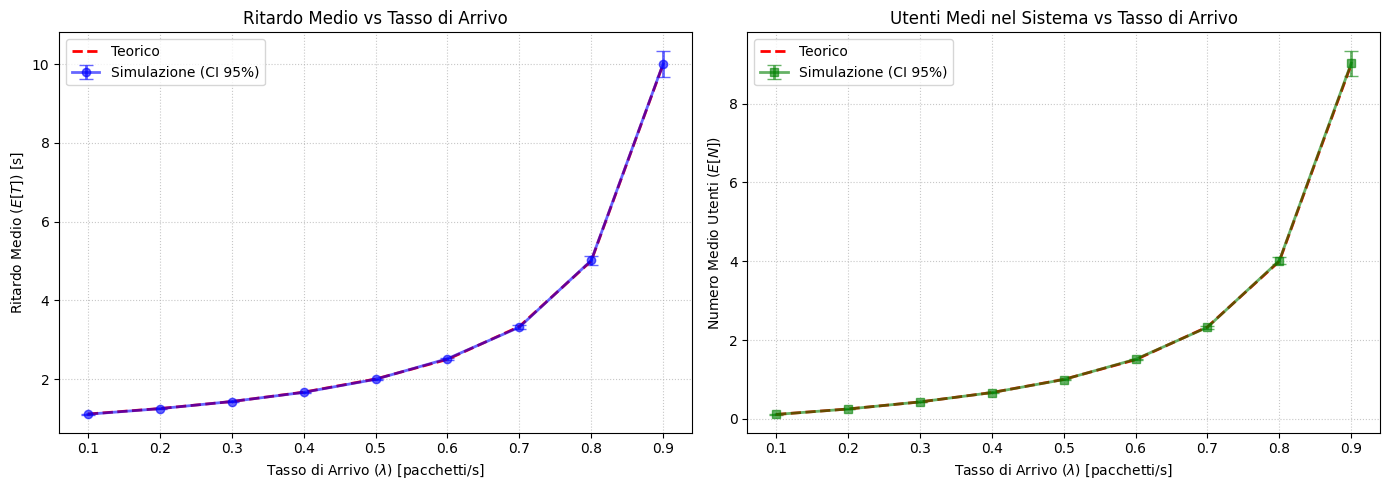

In [6]:
# Parametri dell'esperimento
MU = 1.0                # Tasso di servizio fisso (mu)
lambdas = np.linspace(0.1, 0.9, 9)  # Tassi di arrivo (lambda) da 0.1 a 0.9
n_runs = 20             # Numero di run per ogni lambda per calcolare l'intervallo di confidenza
sim_duration = 50000    # Durata di ogni simulazione

# Strutture per salvare i risultati delle simulazioni
sim_delay_means, sim_delay_cis = [], []
sim_users_means, sim_users_cis = [], []

# Strutture per i valori teorici
teor_delays = []
teor_users = []

print("Inizio simulazioni...")

for lam in lambdas:
    delays_for_lam = []
    users_for_lam = []
    
    # Eseguiamo n_runs per lo stesso lambda variando il seed
    for run in range(n_runs):
        # Usiamo la funzione wrapper creata prima!
        avg_d, avg_u = run_simulation_with_prof_code(
            arr_rate=lam, 
            srv_rate=MU, 
            sim_duration=sim_duration, 
            seed=run # Cambiamo seed ad ogni run
        )
        delays_for_lam.append(avg_d)
        users_for_lam.append(avg_u)
        
    # Calcolo Medie
    mean_d = np.mean(delays_for_lam)
    mean_u = np.mean(users_for_lam)
    
    # TASK 1-b
    # Calcolo Intervalli di Confidenza al 95% (usando t di Student)
    ci_d = st.sem(delays_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1)
    ci_u = st.sem(users_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1)
    
    sim_delay_means.append(mean_d)
    sim_delay_cis.append(ci_d)
    sim_users_means.append(mean_u)
    sim_users_cis.append(ci_u)
    
    # Valori teorici M/M/1
    rho = lam / MU
    teor_delays.append(1 / (MU - lam))
    teor_users.append(rho / (1 - rho))

print("Simulazioni completate! Generazione grafici...")

# ==========================================
# PLOTTING DEI RISULTATI (Corretto)
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Ritardo Medio
# Ho aggiunto alpha=0.6 per rendere la simulazione trasparente e far vedere la linea rossa sotto
ax1.errorbar(lambdas, sim_delay_means, yerr=sim_delay_cis, fmt='-o', color='b', capsize=5, alpha=0.6, linewidth=2, label='Simulazione (CI 95%)')
ax1.plot(lambdas, teor_delays, '--r', linewidth=2, label='Teorico')
ax1.set_title('Ritardo Medio vs Tasso di Arrivo')
# Aggiunta la 'r' prima delle stringhe per risolvere il SyntaxWarning
ax1.set_xlabel(r'Tasso di Arrivo ($\lambda$) [pacchetti/s]')
ax1.set_ylabel(r'Ritardo Medio ($E[T]$) [s]')
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

# Grafico 2: Numero Medio di Utenti
ax2.errorbar(lambdas, sim_users_means, yerr=sim_users_cis, fmt='-s', color='g', capsize=5, alpha=0.6, linewidth=2, label='Simulazione (CI 95%)')
ax2.plot(lambdas, teor_users, '--r', linewidth=2, label='Teorico')
ax2.set_title('Utenti Medi nel Sistema vs Tasso di Arrivo')
ax2.set_xlabel(r'Tasso di Arrivo ($\lambda$) [pacchetti/s]') # Aggiunta la 'r'
ax2.set_ylabel(r'Numero Medio Utenti ($E[N]$)') # Aggiunta la 'r'
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

Esecuzione simulazione breve in corso...
Finito! Generazione grafico...


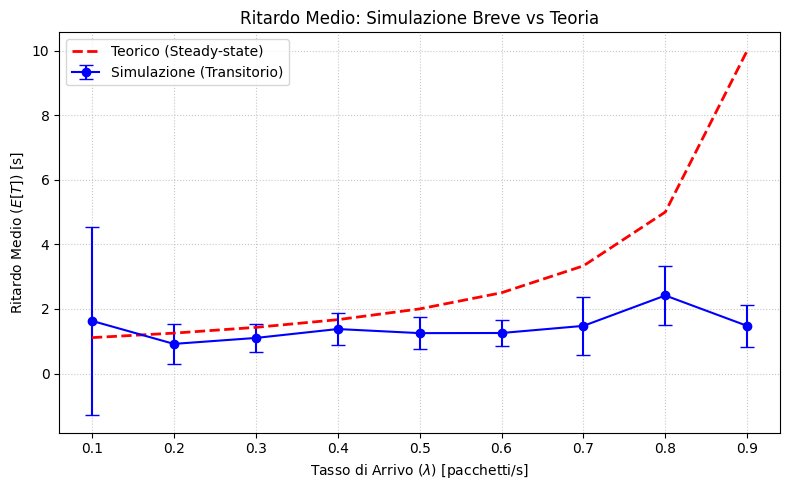

In [7]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

# ==========================================
# PARAMETRI VOLONTARIAMENTE "SBAGLIATI"
# ==========================================
MU = 1.0                
lambdas = np.linspace(0.1, 0.9, 9)  
n_runs = 3              # Pochissime repliche (tanto rumore statistico)
sim_duration = 30       # Durata ridicola (solo 30 secondi di simulazione!)

sim_delay_means, sim_delay_cis = [], []
teor_delays = []

print("Esecuzione simulazione breve in corso...")

for lam in lambdas:
    delays_for_lam = []
    
    for run in range(n_runs):
        # Usiamo sempre la stessa funzione della prof!
        avg_d, _ = run_simulation_with_prof_code(
            arr_rate=lam, 
            srv_rate=MU, 
            sim_duration=sim_duration, 
            seed=run
        )
        delays_for_lam.append(avg_d)
        
    mean_d = np.mean(delays_for_lam)
    # Calcolo CI (anche se con n=3 è poco indicativo)
    ci_d = st.sem(delays_for_lam) * st.t.ppf((1 + 0.95) / 2., n_runs-1) if n_runs > 1 else 0
    
    sim_delay_means.append(mean_d)
    sim_delay_cis.append(ci_d)
    
    # Valore teorico
    teor_delays.append(1 / (MU - lam))

print("Finito! Generazione grafico...")

# ==========================================
# PLOTTING DEI RISULTATI
# ==========================================
plt.figure(figsize=(8, 5))

# Curva della simulazione (sarà molto bassa e tremolante)
plt.errorbar(lambdas, sim_delay_means, yerr=sim_delay_cis, fmt='-o', color='b', capsize=5, label='Simulazione (Transitorio)')

# Curva Teorica (quella corretta a regime)
plt.plot(lambdas, teor_delays, '--r', linewidth=2, label='Teorico (Steady-state)')

plt.title('Ritardo Medio: Simulazione Breve vs Teoria')
plt.xlabel(r'Tasso di Arrivo ($\lambda$) [pacchetti/s]')
plt.ylabel(r'Ritardo Medio ($E[T]$) [s]')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

# TASK 2: Multi-Server System (M/M/c) with Finite Buffer

## Objective
Compare single-server vs multi-server systems (2 transmitters) with shared finite buffer.
Test different buffer sizes and analyze:
- Packet losses
- Buffer occupancy
- Loss probability
- Server busy time


In [ ]:
# Multi-Server (M/M/c) Simulator with Finite Buffer
# ==============================================================================

class MeasureMMc:
    """Statistics for M/M/c queue with finite buffer"""
    def __init__(self):
        self.arr = 0              # Number of arrivals
        self.dep = 0              # Number of departures
        self.dropped = 0          # Number of dropped packets (buffer full)
        self.ut = 0               # Cumulative integral of users in system
        self.ut_buffer = 0        # Cumulative integral of users in buffer (waiting)
        self.oldT = 0             # Last event time
        self.delay = 0            # Cumulative delay (time in system)
        self.wait_delay = 0       # Cumulative waiting delay (time in buffer before service)
        self.wait_count = 0       # Count of packets that experienced waiting
        self.busy_time = None     # List of busy times per server
        self.server_busy_time = 0 # Total busy time across all servers
        
    def reset(self, num_servers):
        self.arr = 0
        self.dep = 0
        self.dropped = 0
        self.ut = 0
        self.ut_buffer = 0
        self.oldT = 0
        self.delay = 0
        self.wait_delay = 0
        self.wait_count = 0
        self.busy_time = [0] * num_servers
        self.server_busy_time = 0

class ServerMMc:
    """Server for M/M/c system"""
    def __init__(self, server_id):
        self.id = server_id
        self.idle = True
        self.client_in_service = None  # Track which client is being served
        self.service_start_time = 0

def run_simulation_mmc(
    arr_rate,           # Arrival rate (lambda)
    srv_rate,           # Service rate per server (mu)
    num_servers,        # Number of servers (c)
    buffer_size,        # -1 for infinite, else finite buffer
    sim_duration=50000,
    seed=42
):
    """
    Simulate M/M/c queue with finite/infinite buffer - CORRECTED VERSION
    
    Returns:
        dict with metrics: avg_delay, avg_users, loss_prob, avg_buffer_occ, avg_wait_delay, etc.
    """
    global ARRIVAL, SERVICE, TYPE1, data, MM1
    
    random.seed(seed)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    
    # Initialize
    data = MeasureMMc()
    data.reset(num_servers)
    MM1 = []  # Queue/buffer
    
    servers = [ServerMMc(i) for i in range(num_servers)]
    users_in_system = 0
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival", None))
    
    while time < sim_duration:
        event = FES.get()
        time = event[0]
        event_type = event[1]
        
        # Update statistics based on time increments
        data.ut += users_in_system * (time - data.oldT)
        data.ut_buffer += len(MM1) * (time - data.oldT)
        data.oldT = time
        
        if event_type == "arrival":
            data.arr += 1
            
            # Try to assign to an idle server
            idle_server = None
            for srv in servers:
                if srv.idle:
                    idle_server = srv
                    break
            
            if idle_server is not None:
                # Start service immediately
                idle_server.idle = False
                client = Client(TYPE1, time)
                idle_server.client_in_service = client
                idle_server.service_start_time = time
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", idle_server.id))
                users_in_system += 1
                
            else:
                # All servers busy - try to add to buffer
                if buffer_size == -1:  # Infinite buffer
                    client = Client(TYPE1, time)
                    MM1.append(client)
                    users_in_system += 1
                elif len(MM1) < buffer_size:  # Finite buffer with space
                    client = Client(TYPE1, time)
                    MM1.append(client)
                    users_in_system += 1
                else:
                    # Buffer full - drop packet
                    data.dropped += 1
            
            # Schedule next arrival
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival", None))
            
        elif event_type == "departure":
            server_id = event[2]
            server = servers[server_id]
            
            # Calculate delay for DEPARTING customer (the one finishing service now)
            if server.client_in_service is not None:
                client_departing = server.client_in_service
                
                # Time in system = arrival -> departure
                time_in_system = time - client_departing.arrival_time
                data.delay += time_in_system
                data.dep += 1
                
                # Update busy time
                service_duration = time - server.service_start_time
                data.busy_time[server_id] += service_duration
                data.server_busy_time += service_duration
                
                users_in_system -= 1
            
            # Now serve next customer from buffer (if any)
            if len(MM1) > 0:
                client = MM1.pop(0)
                server.idle = False
                server.client_in_service = client
                server.service_start_time = time
                
                # Track waiting delay: time from arrival to service start
                wait_time = time - client.arrival_time
                data.wait_delay += wait_time
                data.wait_count += 1
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", server_id))
                users_in_system += 1
            else:
                server.idle = True
                server.client_in_service = None
    
    # Calculate metrics
    avg_delay = data.delay / data.dep if data.dep > 0 else 0
    avg_users = data.ut / time if time > 0 else 0
    avg_buffer_occ = data.ut_buffer / time if time > 0 else 0
    loss_prob = data.dropped / data.arr if data.arr > 0 else 0
    avg_wait_delay = data.wait_delay / data.wait_count if data.wait_count > 0 else 0
    util_per_server = [busy / time for busy in data.busy_time]
    total_util = data.server_busy_time / (num_servers * time) if time > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'avg_users': avg_users,
        'loss_prob': loss_prob,
        'avg_buffer_occ': avg_buffer_occ,
        'avg_wait_delay': avg_wait_delay,
        'wait_count': data.wait_count,
        'dropped': data.dropped,
        'transmitted': data.dep,
        'util_per_server': util_per_server,
        'total_util': total_util
    }

def queue_pop(queue):
    """Remove and return first element from queue"""
    if len(queue) > 0:
        return queue.pop(0)
    return None


In [14]:
# Task 2.a: Compare Single-Server vs Multi-Server (2 servers) with Different Buffer Sizes
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters - REDUCED for faster execution
MU = 1.0                # Service rate per server
lambdas = np.linspace(0.5, 1.8, 7)  # Arrival rates (rho will vary)
n_runs = 5              # REDUCED: Number of runs per configuration (was 10)
sim_duration = 50000    # REDUCED: Simulation duration (was 100000)
buffer_sizes = [-1, 10, 5, 2, 0]  # -1=infinite, then finite buffers, 0=no buffer
labels_buffer = ['Infinite', 'B=10', 'B=5', 'B=2', 'No Buffer']

print("=========================================")
print("TASK 2.a: Single-Server vs Multi-Server")
print("=========================================\n")

# Storage for results
results = {
    'M/M/1': {'delay': [], 'loss': [], 'buffer_occ': [], 'util': []},
    'M/M/2': {buf: {'delay': [], 'loss': [], 'buffer_occ': [], 'util': []} 
              for buf in buffer_sizes}
}

# 1. Single-Server (M/M/1) - using existing code
print("Running M/M/1 simulations...")
for lam in lambdas:
    delays_lam = []
    
    for run in range(n_runs):
        avg_d, avg_u = run_simulation_with_prof_code(
            arr_rate=lam,
            srv_rate=MU,
            sim_duration=sim_duration,
            seed=run
        )
        delays_lam.append(avg_d)
    
    results['M/M/1']['delay'].append(np.mean(delays_lam))
    results['M/M/1']['loss'].append(0)  # No losses with infinite buffer
    results['M/M/1']['buffer_occ'].append(0)  # N/A for M/M/1
    results['M/M/1']['util'].append(lam / MU)  # Utilization

print("Running M/M/2 simulations...")

# 2. Multi-Server with different buffer sizes
for lam in lambdas:
    rho = lam / MU
    print(f"\n  Lambda={lam:.2f} (rho={rho:.2f}):")
    
    for buf_idx, buf_size in enumerate(buffer_sizes):
        delays_lam = []
        losses_lam = []
        buffer_occs_lam = []
        utils_lam = []
        
        for run in range(n_runs):
            result = run_simulation_mmc(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size=buf_size,
                sim_duration=sim_duration,
                seed=run
            )
            delays_lam.append(result['avg_delay'])
            losses_lam.append(result['loss_prob'])
            buffer_occs_lam.append(result['avg_buffer_occ'])
            utils_lam.append(result['total_util'])
        
        results['M/M/2'][buf_size]['delay'].append(np.mean(delays_lam))
        results['M/M/2'][buf_size]['loss'].append(np.mean(losses_lam))
        results['M/M/2'][buf_size]['buffer_occ'].append(np.mean(buffer_occs_lam))
        results['M/M/2'][buf_size]['util'].append(np.mean(utils_lam))
        
        print(f"    Buffer {labels_buffer[buf_idx]}: loss={np.mean(losses_lam):.4f}, delay={np.mean(delays_lam):.4f}s")

print("\n✓ Simulations completed!")


TASK 2.a: Single-Server vs Multi-Server

Running M/M/1 simulations...
Running M/M/2 simulations...

  Lambda=0.50 (rho=0.50):
    Buffer Infinite: loss=0.0000, delay=0.0682s
    Buffer B=10: loss=0.0000, delay=0.0682s
    Buffer B=5: loss=0.0001, delay=0.0660s
    Buffer B=2: loss=0.0047, delay=0.0571s
    Buffer No Buffer: loss=0.0779, delay=0.0000s

  Lambda=0.72 (rho=0.72):
    Buffer Infinite: loss=0.0000, delay=0.1509s
    Buffer B=10: loss=0.0000, delay=0.1489s
    Buffer B=5: loss=0.0009, delay=0.1477s
    Buffer B=2: loss=0.0160, delay=0.1073s
    Buffer No Buffer: loss=0.1336, delay=0.0000s

  Lambda=0.93 (rho=0.93):
    Buffer Infinite: loss=0.0000, delay=0.2858s
    Buffer B=10: loss=0.0001, delay=0.2879s
    Buffer B=5: loss=0.0038, delay=0.2614s
    Buffer B=2: loss=0.0362, delay=0.1642s
    Buffer No Buffer: loss=0.1848, delay=0.0000s

  Lambda=1.15 (rho=1.15):
    Buffer Infinite: loss=0.0000, delay=0.5026s
    Buffer B=10: loss=0.0006, delay=0.4852s
    Buffer B=5: loss

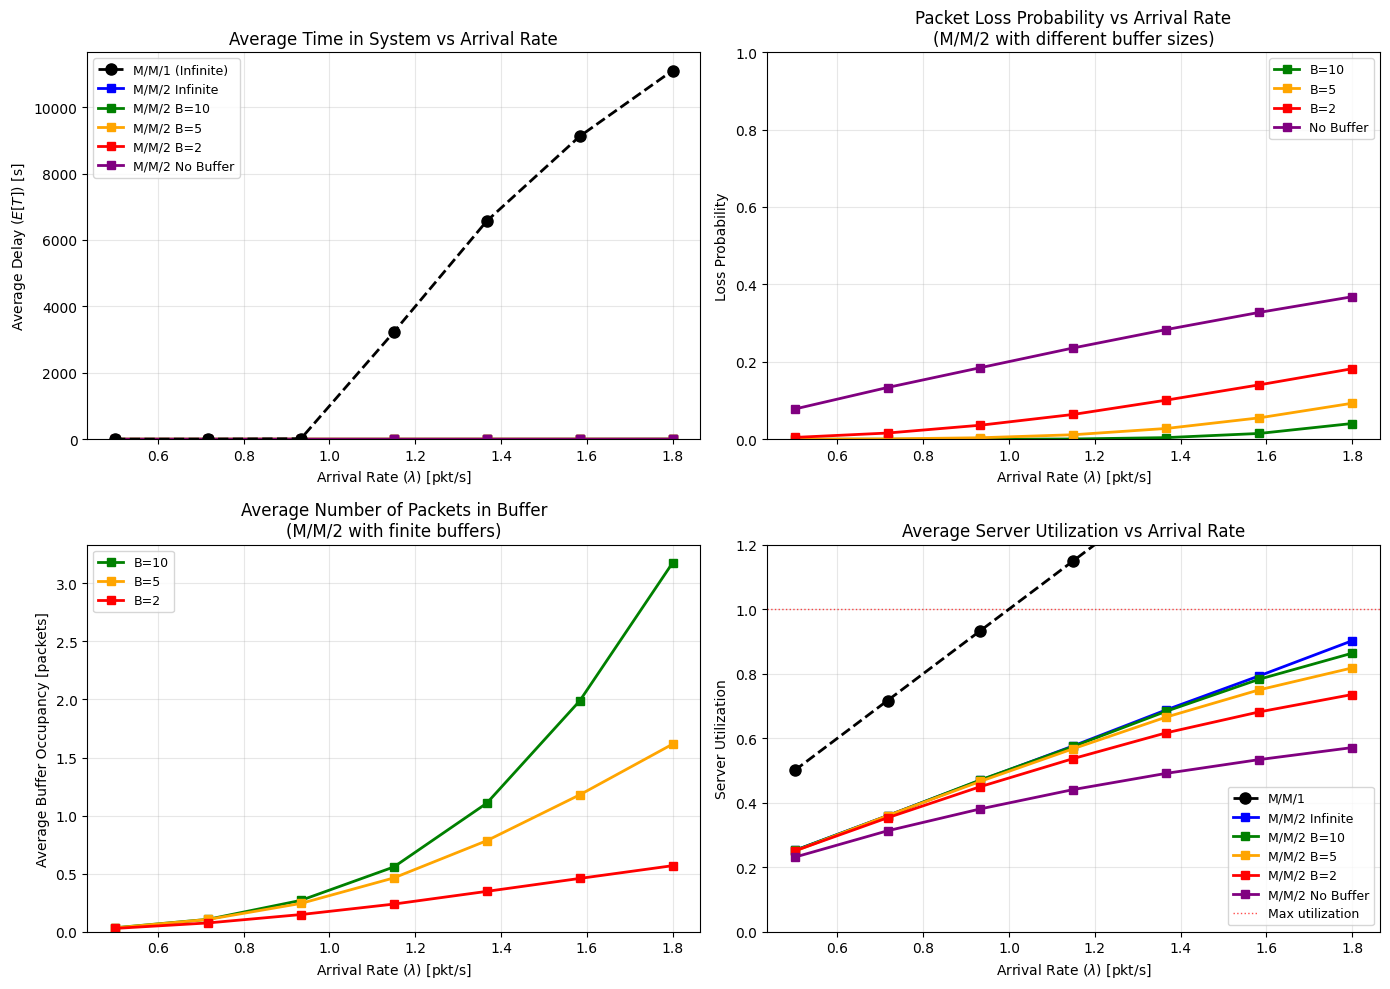


OBSERVATIONS - Task 2.b:
✓ M/M/2 provides better performance than M/M/1 (lower delays)
✓ Finite buffer significantly increases packet losses at high λ
✓ Buffer occupancy increases with arrival rate
✓ M/M/2 allows higher utilization without instability


In [15]:
# Task 2.b: Visualize Results - Impact of Buffer Size on Performance
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Color scheme for multi-server buffers
colors_mm2 = ['blue', 'green', 'orange', 'red', 'purple']

# ---- Plot 1: Average Delay ----
ax = axes[0, 0]
ax.plot(lambdas, results['M/M/1']['delay'], 'k--o', linewidth=2, markersize=8, label='M/M/1 (Infinite)', zorder=5)
for buf_idx, buf_size in enumerate(buffer_sizes):
    ax.plot(lambdas, results['M/M/2'][buf_size]['delay'], 
            color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
            label=f'M/M/2 {labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel(r'Average Delay ($E[T]$) [s]')
ax.set_title('Average Time in System vs Arrival Rate')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# ---- Plot 2: Loss Probability ----
ax = axes[0, 1]
for buf_idx, buf_size in enumerate(buffer_sizes):
    if buf_size >= 0:  # Skip infinite buffer (no losses)
        ax.plot(lambdas, results['M/M/2'][buf_size]['loss'], 
                color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
                label=f'{labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel('Loss Probability')
ax.set_title('Packet Loss Probability vs Arrival Rate\n(M/M/2 with different buffer sizes)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim([0, 1])

# ---- Plot 3: Average Buffer Occupancy ----
ax = axes[1, 0]
for buf_idx, buf_size in enumerate(buffer_sizes):
    if buf_size > 0:  # Only show finite buffers
        ax.plot(lambdas, results['M/M/2'][buf_size]['buffer_occ'], 
                color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
                label=f'{labels_buffer[buf_idx]}')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel('Average Buffer Occupancy [packets]')
ax.set_title('Average Number of Packets in Buffer\n(M/M/2 with finite buffers)')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim(bottom=0)

# ---- Plot 4: Server Utilization ----
ax = axes[1, 1]
ax.plot(lambdas, results['M/M/1']['util'], 'k--o', linewidth=2, markersize=8, label='M/M/1', zorder=5)
for buf_idx, buf_size in enumerate(buffer_sizes):
    ax.plot(lambdas, results['M/M/2'][buf_size]['util'], 
            color=colors_mm2[buf_idx], marker='s', linewidth=2, markersize=6,
            label=f'M/M/2 {labels_buffer[buf_idx]}')
ax.axhline(y=1.0, color='red', linestyle=':', linewidth=1, alpha=0.7, label='Max utilization')
ax.set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
ax.set_ylabel('Server Utilization')
ax.set_title('Average Server Utilization vs Arrival Rate')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
ax.set_ylim([0, 1.2])

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OBSERVATIONS - Task 2.b:")
print("="*60)
print("✓ M/M/2 provides better performance than M/M/1 (lower delays)")
print("✓ Finite buffer significantly increases packet losses at high λ")
print("✓ Buffer occupancy increases with arrival rate")
print("✓ M/M/2 allows higher utilization without instability")
print("="*60)


# TASK 2.c: Shared vs Separate Buffers in M/M/2

Compare performance when:
- **Shared buffer**: One queue for both servers (current implementation)
- **Separate buffers**: Each server has its own queue/buffer


In [ ]:
# Simulator for M/M/c with SEPARATE buffers (one per server) - CORRECTED
# ==============================================================================

def run_simulation_mmc_separate_buffers(
    arr_rate,
    srv_rate,
    num_servers,
    buffer_size_per_server,  # Buffer size per server
    sim_duration=50000,
    seed=42
):
    """
    Simulate M/M/c with SEPARATE buffers (one per server) - CORRECTED VERSION
    
    Arrival assignment: Round-robin to least-occupied queue
    """
    global ARRIVAL, SERVICE, TYPE1, data
    
    random.seed(seed)
    ARRIVAL = 1.0 / arr_rate if arr_rate > 0 else float('inf')
    SERVICE = 1.0 / srv_rate if srv_rate > 0 else float('inf')
    
    # Initialize
    data_sep = MeasureMMc()
    data_sep.reset(num_servers)
    
    # Separate queue per server
    queues = [[] for _ in range(num_servers)]
    servers = [ServerMMc(i) for i in range(num_servers)]
    users_in_system = 0
    total_in_buffers = 0
    
    time = 0
    FES = PriorityQueue()
    FES.put((0, "arrival", None))
    
    while time < sim_duration:
        event = FES.get()
        time = event[0]
        event_type = event[1]
        
        # Update statistics
        data_sep.ut += users_in_system * (time - data_sep.oldT)
        data_sep.ut_buffer += total_in_buffers * (time - data_sep.oldT)
        data_sep.oldT = time
        
        if event_type == "arrival":
            data_sep.arr += 1
            
            # Find least-occupied queue
            min_queue_len = float('inf')
            best_server_id = 0
            for i, queue in enumerate(queues):
                if servers[i].idle:
                    # Server is idle, assign immediately
                    best_server_id = i
                    break
                elif len(queue) < min_queue_len:
                    min_queue_len = len(queue)
                    best_server_id = i
            
            # Try to assign to best server
            assigned = False
            
            if servers[best_server_id].idle:
                # Server idle - start service
                servers[best_server_id].idle = False
                client = Client(TYPE1, time)
                servers[best_server_id].client_in_service = client
                servers[best_server_id].service_start_time = time
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", best_server_id))
                users_in_system += 1
                assigned = True
                
            else:
                # Server busy - try buffer
                if buffer_size_per_server == -1:  # Infinite
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
                elif len(queues[best_server_id]) < buffer_size_per_server:
                    client = Client(TYPE1, time)
                    queues[best_server_id].append(client)
                    users_in_system += 1
                    total_in_buffers += 1
                    assigned = True
            
            if not assigned:
                # Packet dropped
                data_sep.dropped += 1
            
            # Schedule next arrival
            inter_arrival = random.expovariate(1.0 / ARRIVAL)
            FES.put((time + inter_arrival, "arrival", None))
            
        elif event_type == "departure":
            server_id = event[2]
            server = servers[server_id]
            
            # Calculate delay for DEPARTING customer
            if server.client_in_service is not None:
                client_departing = server.client_in_service
                
                # Time in system
                time_in_system = time - client_departing.arrival_time
                data_sep.delay += time_in_system
                data_sep.dep += 1
                
                # Update busy time
                service_duration = time - server.service_start_time
                data_sep.busy_time[server_id] += service_duration
                data_sep.server_busy_time += service_duration
                
                users_in_system -= 1
            
            # Now serve next customer from this server's queue (if any)
            if len(queues[server_id]) > 0:
                client = queues[server_id].pop(0)
                total_in_buffers -= 1
                
                server.idle = False
                server.client_in_service = client
                server.service_start_time = time
                
                # Track waiting delay: time from arrival to service start
                wait_time = time - client.arrival_time
                data_sep.wait_delay += wait_time
                data_sep.wait_count += 1
                
                service_time = random.expovariate(1.0 / SERVICE)
                FES.put((time + service_time, "departure", server_id))
                users_in_system += 1
            else:
                server.idle = True
                server.client_in_service = None
    
    # Calculate metrics
    avg_delay = data_sep.delay / data_sep.dep if data_sep.dep > 0 else 0
    avg_users = data_sep.ut / time if time > 0 else 0
    avg_buffer_occ = data_sep.ut_buffer / time if time > 0 else 0
    loss_prob = data_sep.dropped / data_sep.arr if data_sep.arr > 0 else 0
    avg_wait_delay = data_sep.wait_delay / data_sep.wait_count if data_sep.wait_count > 0 else 0
    util_per_server = [busy / time for busy in data_sep.busy_time]
    total_util = data_sep.server_busy_time / (num_servers * time) if time > 0 else 0
    
    return {
        'avg_delay': avg_delay,
        'avg_users': avg_users,
        'loss_prob': loss_prob,
        'avg_buffer_occ': avg_buffer_occ,
        'avg_wait_delay': avg_wait_delay,
        'util_per_server': util_per_server,
        'total_util': total_util,
        'dropped': data_sep.dropped
    }



TASK 2.c: Shared vs Separate Buffers Comparison

Testing λ=0.80...
  Buffer size: 5
  Buffer size: 10
Testing λ=1.20...
  Buffer size: 5
  Buffer size: 10
Testing λ=1.60...
  Buffer size: 5
  Buffer size: 10
✓ Comparison simulations completed!



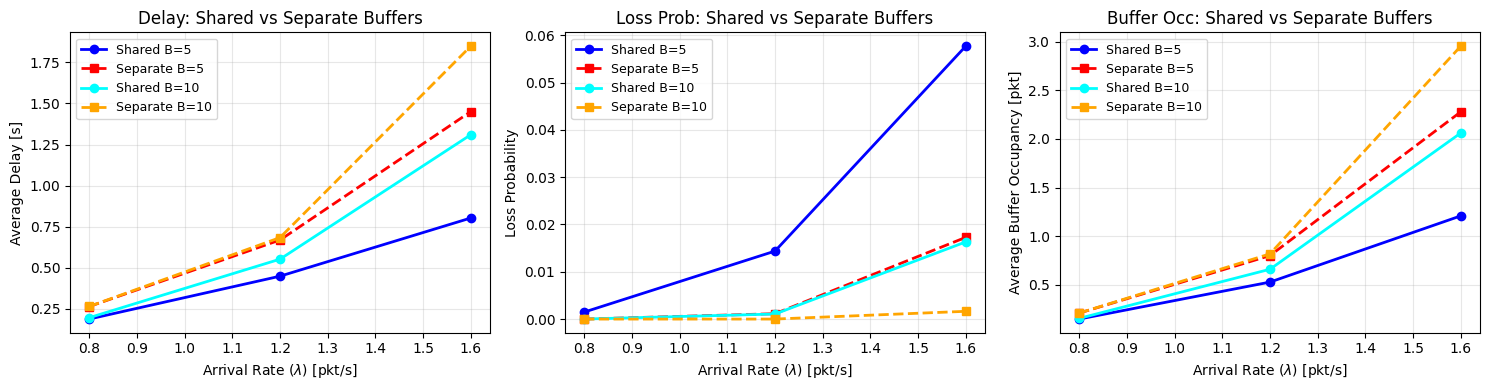


KEY FINDINGS - Shared vs Separate Buffers:
✓ Shared buffer typically offers BETTER performance
  - Lower delays due to better load balancing
  - Lower loss probability (more efficient space usage)
✓ Separate buffers can lead to UNBALANCED load
  - One server's queue may fill while other is less loaded
  - Higher packet drops and delays


In [12]:
# Comparison: Shared Buffer vs Separate Buffers
# ==============================================================================

print("\n" + "="*60)
print("TASK 2.c: Shared vs Separate Buffers Comparison")
print("="*60 + "\n")

# Test parameters
MU = 1.0
lambdas_test = np.array([0.8, 1.2, 1.6])  # Different load scenarios
n_runs_compare = 8
sim_duration_compare = 100000
buffer_configs = [5, 10]  # Test with these buffer sizes

results_comparison = {
    'shared': {buf: {'delay': [], 'loss': [], 'buffer_occ': []} for buf in buffer_configs},
    'separate': {buf: {'delay': [], 'loss': [], 'buffer_occ': []} for buf in buffer_configs}
}

for lam in lambdas_test:
    print(f"Testing λ={lam:.2f}...")
    
    for buf_size in buffer_configs:
        print(f"  Buffer size: {buf_size}")
        
        delays_shared = []
        losses_shared = []
        buffer_occs_shared = []
        
        delays_sep = []
        losses_sep = []
        buffer_occs_sep = []
        
        for run in range(n_runs_compare):
            # Shared buffer
            result_sh = run_simulation_mmc(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size=buf_size,
                sim_duration=sim_duration_compare,
                seed=run
            )
            delays_shared.append(result_sh['avg_delay'])
            losses_shared.append(result_sh['loss_prob'])
            buffer_occs_shared.append(result_sh['avg_buffer_occ'])
            
            # Separate buffers
            result_sep = run_simulation_mmc_separate_buffers(
                arr_rate=lam,
                srv_rate=MU,
                num_servers=2,
                buffer_size_per_server=buf_size,
                sim_duration=sim_duration_compare,
                seed=run
            )
            delays_sep.append(result_sep['avg_delay'])
            losses_sep.append(result_sep['loss_prob'])
            buffer_occs_sep.append(result_sep['avg_buffer_occ'])
        
        results_comparison['shared'][buf_size]['delay'].append(np.mean(delays_shared))
        results_comparison['shared'][buf_size]['loss'].append(np.mean(losses_shared))
        results_comparison['shared'][buf_size]['buffer_occ'].append(np.mean(buffer_occs_shared))
        
        results_comparison['separate'][buf_size]['delay'].append(np.mean(delays_sep))
        results_comparison['separate'][buf_size]['loss'].append(np.mean(losses_sep))
        results_comparison['separate'][buf_size]['buffer_occ'].append(np.mean(buffer_occs_sep))

print("✓ Comparison simulations completed!\n")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors_shared = ['blue', 'cyan']
colors_sep = ['red', 'orange']

for buf_idx, buf_size in enumerate(buffer_configs):
    # Plot 1: Delay
    ax = axes[0]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['delay'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['delay'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')
    
    # Plot 2: Loss probability
    ax = axes[1]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['loss'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['loss'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')
    
    # Plot 3: Buffer occupancy
    ax = axes[2]
    ax.plot(lambdas_test, results_comparison['shared'][buf_size]['buffer_occ'],
            color=colors_shared[buf_idx], marker='o', linestyle='-', linewidth=2,
            label=f'Shared B={buf_size}')
    ax.plot(lambdas_test, results_comparison['separate'][buf_size]['buffer_occ'],
            color=colors_sep[buf_idx], marker='s', linestyle='--', linewidth=2,
            label=f'Separate B={buf_size}')

axes[0].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[0].set_ylabel('Average Delay [s]')
axes[0].set_title('Delay: Shared vs Separate Buffers')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=9)

axes[1].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[1].set_ylabel('Loss Probability')
axes[1].set_title('Loss Prob: Shared vs Separate Buffers')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

axes[2].set_xlabel(r'Arrival Rate ($\lambda$) [pkt/s]')
axes[2].set_ylabel('Average Buffer Occupancy [pkt]')
axes[2].set_title('Buffer Occ: Shared vs Separate Buffers')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY FINDINGS - Shared vs Separate Buffers:")
print("="*60)
print("✓ Shared buffer typically offers BETTER performance")
print("  - Lower delays due to better load balancing")
print("  - Lower loss probability (more efficient space usage)")
print("✓ Separate buffers can lead to UNBALANCED load")
print("  - One server's queue may fill while other is less loaded")
print("  - Higher packet drops and delays")
print("="*60)
